<a href="https://colab.research.google.com/github/ericnmt/htd-benchmarking/blob/main/notebooks/T800-HT-ML-Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HT detection proof-of-concept, time-series analysis (T-800)

Eric Johnson

## Data Preparation

### 1. Install requirements

In [3]:
# Install numpy, matplotlib, scikit-learn, pyod
!uv init .
!uv add numpy matplotlib scikit-learn
!pip install pyod
!rm -rf sample_data
!mkdir -p src/content/data/
import numpy as np
import matplotlib.pyplot as plt
import pyod as pyod
import sklearn
import torch
import os

# Drive mounts for dataset uploaded to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Initialized project `content` at `/content`
Using CPython 3.13.15 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 18 packages in 490ms
Prepared 18 packages in 5.95s
Installed 18 packages in 83ms
 + cloudpickle==3.1.2
 + content==0.1.0 (from file:///content)
 + contourpy==1.4.0
 + cycler==0.12.1
 + fonttools==4.66.0
 + joblib==1.6.0
 + kiwisolver==1.5.1
 + matplotlib==3.11.2
 + narwhals==2.26.0
 + numpy==2.5.3
 + packaging==26.3
 + pillow==12.3.0
 + pyparsing==3.3.3
 + python-dateutil==2.9.0.post0
 + scikit-learn==1.9.1
 + scipy==1.18.1
 + six==1.17.0
 + threadpoolctl==3.7.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.3 MB/s eta 0:00:00


### 1.5 - Intermediate: Run NumPy conversions


Convert the raw data into numpy arrays, using  the ``00_convert.py`` script, upload to the ``content/src/content/data`` path in this notebook.

In [15]:
# Source folder of imported numpy arrays,
# change if uploaded elsewhere
# DATA = "/content/src/content/data/"

# OR sync to drive (change as necessary, keep the /content/drive/MyDrive prefix)
DATA = '/content/drive/MyDrive/HTD-Datasets/T800/'

# Output the name of the numpy array, corresponding properties

files = os.listdir(DATA)

if not files:
  print("No files found, verify that files have been uploaded to the proper path.")

else:
  for file in files:
    X = np.load(DATA + file)
    print(f'{file:12s} shape={X.shape}, dtype={X.dtype}, nan={np.isnan(X).sum()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AES-T800+TrojanDisabled_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanDisabled_2.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanTriggered_1.npy shape=(10000, 2500), dtype=float32, nan=0
AES-T800+TrojanTriggered_2.npy shape=(10000, 2500), dtype=float32, nan=0


Confirm that `shape= (10000, 2500)`, `dtype=float32`, and `nan=0`. This means the data was properly converted.

### Plot Trace Overlays
This step verifies that indices are consistent across arrays. Here, we test the assumption that the trace index is at the same point in time for every trace.

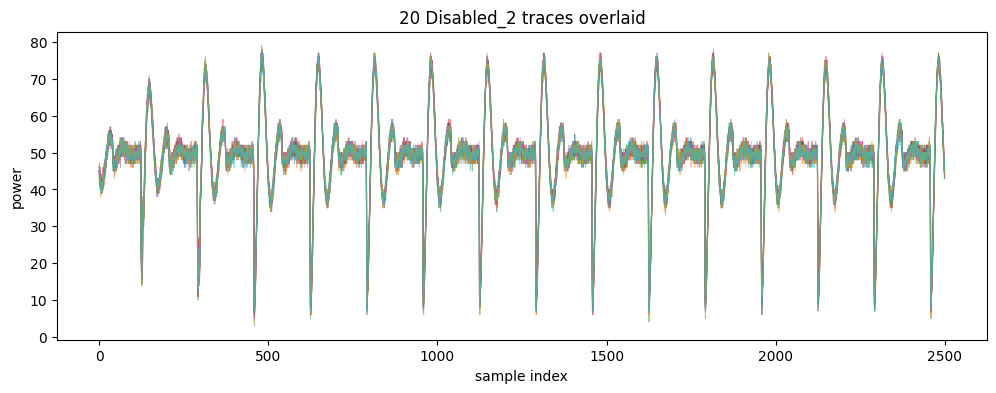

In [16]:
d2 = np.load(f"{DATA}/AES-T800+TrojanDisabled_2.npy")
t2 = np.load(f"{DATA}/AES-T800+TrojanTriggered_2.npy")

os.makedirs("results/figures", exist_ok=True)

plt.figure(figsize=(12,4))
for i in range(20):
  plt.plot(d2[i], alpha=0.5, linewidth=0.7)
plt.title("20 Disabled_2 traces overlaid")
plt.xlabel("sample index"); plt.ylabel("power")
plt.savefig("results/figures/01_alignment.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

We can conclude that incides and power measurements are consistent across all traces.

#### Mean Comparison Plot: Normal vs Triggered
Here, we see if there are any visual changes made by the Trojan trigger, comparing it to the normal data.

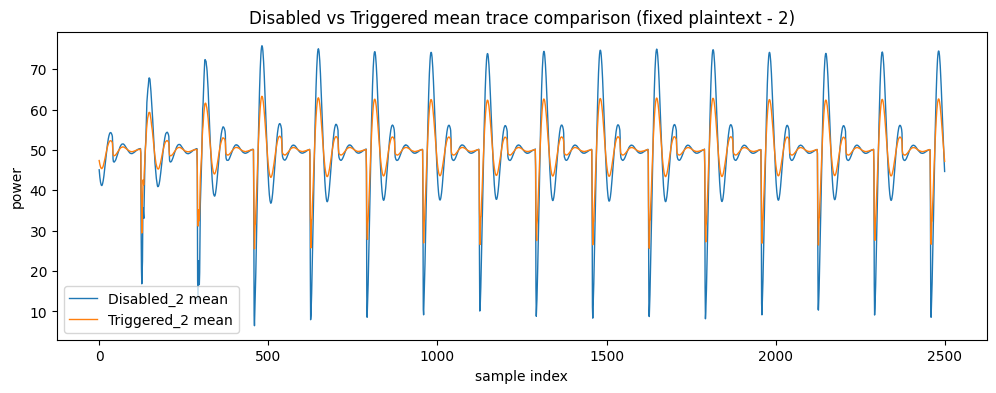

In [17]:
plt.figure(figsize=(12,4))
plt.plot(d2.mean(axis=0), label="Disabled_2 mean", linewidth=1)
plt.plot(t2.mean(axis=0), label="Triggered_2 mean", linewidth=1)
plt.legend()
plt.title("Disabled vs Triggered mean trace comparison (fixed plaintext - 2)")
plt.xlabel("sample index")
plt.ylabel("power")
plt.savefig("results/figures/02_mean_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

We can conclude that there is a noticable impact on the power output of the circuit when a trojan is active.

#### Difference of Means: Normal vs Triggered
Here, we compare the difference of the mean power of both triggered and normal traces. This highlights the magnitude of the difference between the two signals.

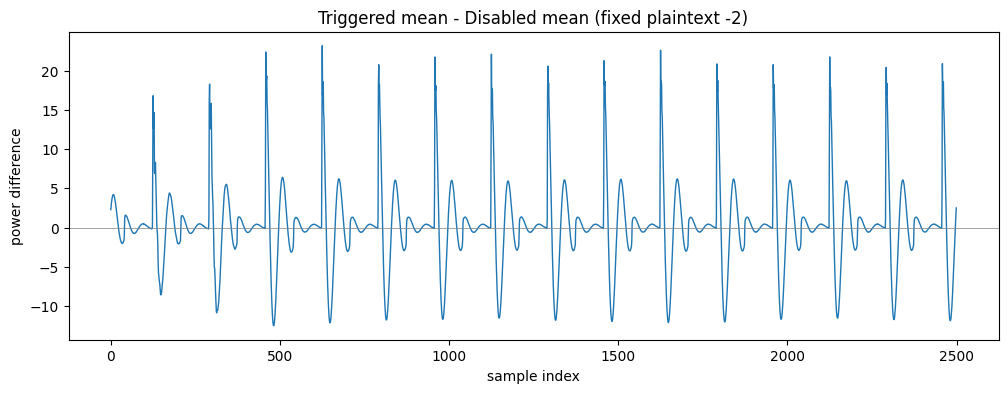

In [18]:
diff = t2.mean(axis=0) - d2.mean(axis=0)
plt.figure(figsize=(12,4))
plt.plot(diff, linewidth=1)
plt.axhline(0, color="gray", linewidth=0.5)
plt.title("Triggered mean - Disabled mean (fixed plaintext -2)")
plt.xlabel("sample index")
plt.ylabel("power difference")
plt.savefig("results/figures/03_diff.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

#### Per-trace Mean Histogram
This plot is the distribution of the average across the entire trace. While separation betwen power averages is trivial, this may not be the case for other trojan variants (T-600 and T-1600, Golabi et. al).

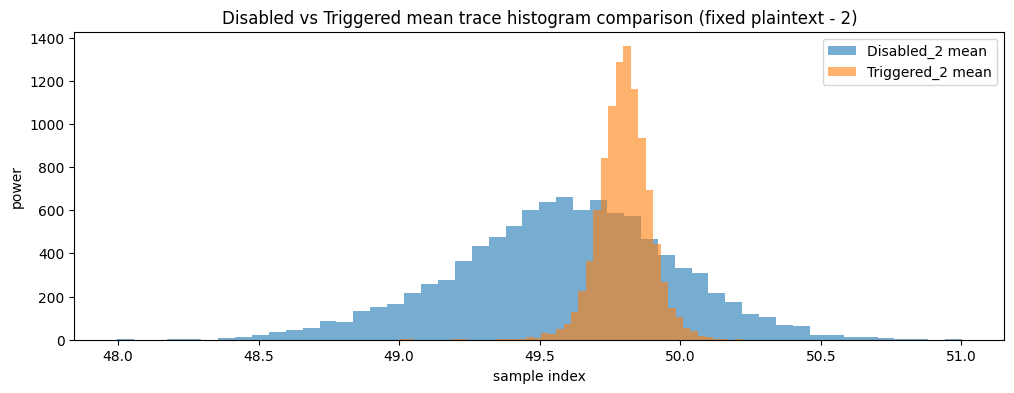

In [19]:
# Load data into d1, t1, d2, t1

d1 = np.load(f"{DATA}/AES-T800+TrojanDisabled_1.npy")
t1 = np.load(f"{DATA}/AES-T800+TrojanTriggered_1.npy")
d2 = np.load(f"{DATA}/AES-T800+TrojanDisabled_2.npy")
t2 = np.load(f"{DATA}/AES-T800+TrojanTriggered_2.npy")


plt.figure(figsize=(12,4))
plt.hist(d2.mean(axis=1), bins=50, alpha=0.6, label = "Disabled_2 mean")
plt.hist(t2.mean(axis=1), bins=50, alpha=0.6, label = "Triggered_2 mean")
plt.legend()
plt.title("Disabled vs Triggered mean trace histogram comparison (fixed plaintext - 2)")
plt.xlabel("sample index")
plt.ylabel("power")
plt.savefig("results/figures/04_hist.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()

#### AUC analysis
This result should be either 0 or 1, showcasing that every anomaly anomaly scores above every normal trace (i.e. there is perfect separation). Note that this is expected for the T-800 data as detector benchmarks scored nearly 99% accuracy in previous work.

In [20]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

# Determine AUC on the first 2000 samples to determine how well anamlous data is separated from normal data
def held_out_auc(disabled, triggered, n_holdout=2000):
  d_test = disabled[-n_holdout:]
  t_test = triggered[-n_holdout:]

  scores = np.concatenate([-d_test.std(axis=1), -t_test.std(axis=1)])
  labels = np.concatenate([np.zeros(len(d_test)), np.ones(len(t_test))])

  return roc_auc_score(labels, scores)

print("AUC, fixed plaintext (_2): ", held_out_auc(d2, t2))
print("AUC, varied plaintext (_1): ", held_out_auc(d1, t1))

AUC, fixed plaintext (_2):  1.0
AUC, varied plaintext (_1):  1.0


### Split Data
Formalize the data splits for training and testing batches. This will be done on fixed plaintext (2) data with 60/40 train/test partitioning.

In [21]:
# 60/40 split on train/test
train_normal = d2[:5000]
test_normal = d2[5000:]
test_anom = t2[:10000]

print(train_normal.shape, test_normal.shape, test_anom.shape)

(5000, 2500) (5000, 2500) (10000, 2500)


### Fit scaler
This step is essential to ensure that feature selection is optimized, preventing data leakage, and for model preparation.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(train_normal)
# compute the mean/std computer per one of 2500 columns, from train_normal
scaler.fit(train_normal)

train_s = scaler.transform(train_normal)
test_norm_s = scaler.transform(test_normal)
test_anom_s = scaler.transform(test_anom)

### Initialize Autoencoder
The framework of choice is PyTorch because of its compatibility with PyOD. We define the autoencoder as a class, with a constructor and functio function(`forward`) to return the latent space layer, $z$, and the reconstructed layer.

In [23]:
import torch.nn as nn

class AutoEncoder(nn.Module):
  """
  AutoEncoder class constructor and forward function

  Constructor: Creates the input, hidden, and latent space layers.
  Forward: Returns the reconstructed layer, and the latent space representation
  """
  def __init__(self):
    super().__init__()
    # Encoder
    self.encoder = nn.Sequential(
        # Imput features compressed as: 2500 -> 512 -> 128 -> 32
        nn.Linear(2500, 512), nn.ReLU(),
        nn.Linear(512, 128), nn.ReLU(),
        nn.Linear(128, 32))  # Latent space, z
    # Decoder
    self.decoder = nn.Sequential(
        # Output features reconstructed as: 32 -> 128 -> 512 -> 2500
        nn.Linear(32, 128), nn.ReLU(),
        nn.Linear(128, 512), nn.ReLU(),
        nn.Linear(512, 2500)) # Reconstructed layer

  def forward(self, x):
    z = self.encoder(x)
    # Return the reconstructed layer, and the latent space representation
    return self.decoder(z), z

### Train Autoencoder

This step consists of training the autoencoder and basic analysis of the training results. The autoencoder was trained with the following:
* T4 TPU
* Adam optimizer (LR = 0.001)
* 20 total epochs. Note that this choice was derived from an *earlier* run which used a validation set, 20 was the most optimal epoch.
* MSE loss

In [25]:
from torch.utils.data import TensorDataset, DataLoader
import copy

N_EPOCHS = 20

device = "cpu"
# Initialize the model object
model = AutoEncoder().to(device)
# Use Adam optimizer with a learn rate of 0.001
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# Compute loss as Mean Squared Error
loss_fn = nn.MSELoss()

# Initialize tensors
train_t = torch.tensor(train_s, dtype=torch.float32)

# Load the dataset into "loader"
loader = DataLoader(TensorDataset(train_t), batch_size = 64, shuffle=True)

train_losses = []

# Train loop, switch model to "train" mode
for epoch in range(N_EPOCHS):
  model.train()
  epoch_loss = 0
  for (batch,) in loader:
    batch = batch.to(device)
    opt.zero_grad()
    recon, _ = model(batch)
    loss = loss_fn(recon, batch)
    loss.backward()
    opt.step()
    epoch_loss += loss.item() * len(batch)
  train_losses.append(epoch_loss / len(train_t))
  print(f"epoch {epoch}: train_loss={train_losses[-1]:.4f}")

print("done")

epoch 0: train_loss=0.4923
epoch 1: train_loss=0.3819
epoch 2: train_loss=0.3777
epoch 3: train_loss=0.3746
epoch 4: train_loss=0.3722
epoch 5: train_loss=0.3706
epoch 6: train_loss=0.3694
epoch 7: train_loss=0.3681
epoch 8: train_loss=0.3673
epoch 9: train_loss=0.3663
epoch 10: train_loss=0.3632
epoch 11: train_loss=0.3610
epoch 12: train_loss=0.3603
epoch 13: train_loss=0.3579
epoch 14: train_loss=0.3561
epoch 15: train_loss=0.3546
epoch 16: train_loss=0.3521
epoch 17: train_loss=0.3496
epoch 18: train_loss=0.3492
epoch 19: train_loss=0.3470
done


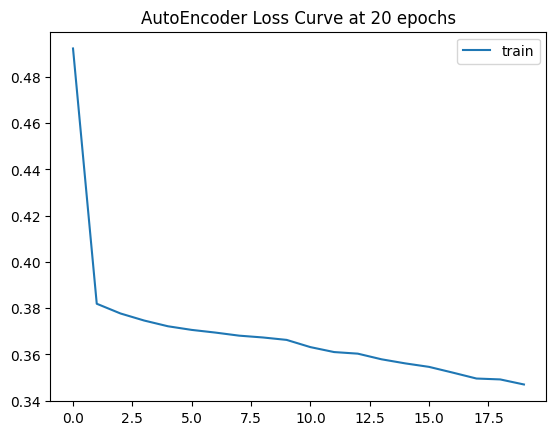

In [26]:
# Loss curve plot analysis
plt.plot(train_losses, label="train")
plt.legend()
plt.title(f"AutoEncoder Loss Curve at {N_EPOCHS} epochs")
plt.show()

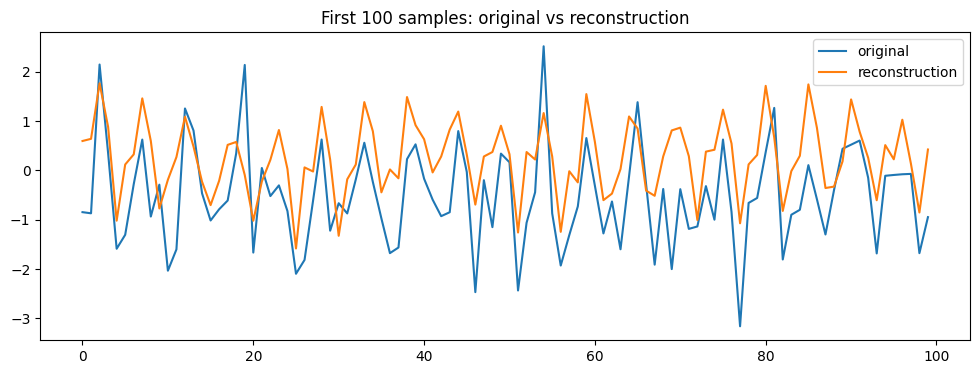

In [27]:
# Analyze reconstructed data
model.eval()

# The range of indexes that the normal and reconstructed trace will be compared.
plot_index_range = 100

# Plotted at the first 100 samples of the original and reconstructed data
plt.figure(figsize=(12,4))
plt.plot(train_s[0][:plot_index_range], label="original")
plt.plot(recon.detach().cpu().numpy()[0][:plot_index_range], label="reconstruction")
plt.legend()
plt.title(f"First {plot_index_range} samples: original vs reconstruction")
plt.show()

If the original and reconstructed plot look similar, then we can conclude that the autoencoder learned, generalized, and reconstructed the features of the original data sufficiently.

### Encode Data Splits
At this step, we encode all the splits using the pre-trained autoencoder. This way, we may incorperate their stasticial models into the algorithm for evaluation.


In [29]:
model.eval() # Switch from training to inference
with torch.no_grad():
  # Encode latent space - training split
  Z_train = model.encoder(train_t.to(device)).cpu().numpy()
  # Encode latent space - test normal split
  Z_test_norm = model.encoder(torch.tensor(test_norm_s, dtype=torch.float32).to(device)).cpu().numpy()
  # Encode latent space - test anomalous split
  Z_test_anom = model.encoder(torch.tensor(test_anom_s, dtype=torch.float32).to(device)).cpu().numpy()

print(Z_train.shape)

(5000, 32)


### Fit and Detect with ECOD
[Empirical Cumulative disribution-based Outlier Detection](https://pyod.readthedocs.io/en/latest/pyod.models.tabular.html#module-pyod.models.ecod) is a parameter free outlier detection algorithm based on empirical CDF functions.Here, we analyze the model's performance using ROC-AUC and Precision-Recall AUC (PR-AUC) scores. NOTE that score values were negated due to ECOD's native output requiring a sign correction.

ROC-AUC: 0.8282
PR-AUC: 0.9276


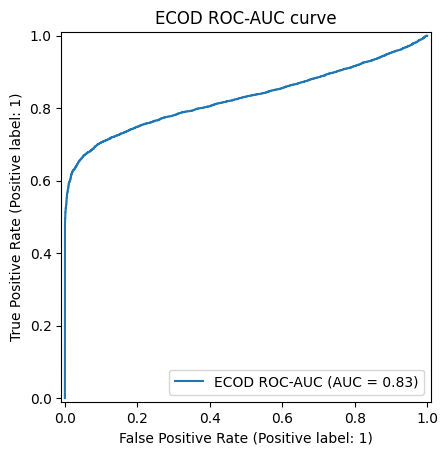

In [30]:
import pyod as pyod
from pyod.models.ecod import ECOD
from sklearn.metrics import roc_auc_score, average_precision_score,confusion_matrix, f1_score

# Initialize classifier instance
clf = ECOD()
# Fit/train model on the latent space representation
clf.fit(Z_train)

# Compute scores (refer to note)
test_norm_scores = -clf.decision_function(Z_test_norm)
test_anom_scores = -clf.decision_function(Z_test_anom)

scores = np.concatenate([test_norm_scores, test_anom_scores])
labels = np.concatenate([np.zeros(len(test_norm_scores)), np.ones(len(test_anom_scores))])
preds = (scores > 0).astype(int)

# ROC AUC
auc = roc_auc_score(labels, scores)
# Precision/Recall AUC
pr_auc = average_precision_score(labels, scores)

print(f"ROC-AUC: {auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

RocCurveDisplay.from_predictions(labels, scores, name="ECOD ROC-AUC")
plt.title(f"ECOD ROC-AUC curve")
plt.show()

In conclusion: THE ECOD algorithm has a AUC of 0.84, which suggests the performance of the model's classification does not meet current state-of-the art standards. The model correctly predicted 1975 traces, but missed 3702 malicious traces. Although, the confusion matrix does report a relatively low false negatives.

### Evaluate Reconstruction Error
Here, we evaluate if the autoencoder actually learned something useful. Ideal case is 1.0.


In [32]:
recon_test_norm, _ = model(torch.tensor(test_norm_s, dtype=torch.float32).to(device))
recon_test_anom, _ = model(torch.tensor(test_anom_s, dtype=torch.float32).to(device))
# Compute MSE of test set - norm set (for normal data)
mse_norm = ((recon_test_norm.detach().cpu().numpy() - test_norm_s) ** 2).mean(axis=1)
# Compute MSE of test set - anom set (for abnormal data)
mse_anom = ((recon_test_anom.detach().cpu().numpy() - test_anom_s) ** 2).mean(axis=1)
recon_scores = np.concatenate([mse_norm, mse_anom])
print("Reconstruction AUC:", roc_auc_score(labels, recon_scores))

Reconstruction AUC: 1.0
